# EDA — Dataset B: MentalChat16K (ShenLab)

| Item | Detail |
|---|---|
| **Source** | `ShenLab/MentalChat16K` (MIT; citation requested: Xu et al., arXiv:2503.13509) |
| **Raw file** | `../data/mh_conversation/raw/dataset_B_mentalchat16k.json` (JSONL) + the two source CSVs for provenance |
| **Fields** | `instruction` (fixed boilerplate — dropped), `input` (patient) → `output` (counselor) |
| **Composition** | ~10K synthetic GPT-3.5 dialogues + ~6K paraphrased caregiver-interview transcripts |
| **Split** | 70/20/10 grouped by user text, seed 42 — the prior study's row-level split leaked ~10 identical inputs across splits |

In [1]:
# Cell 1 — Imports + load raw JSONL
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiktoken

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # ft root (ft_utils, config)
import ft_utils

DKEY = "mentalchat16k"
C_SYN = "#4477AA"      # blue   — synthetic rows
C_ITV = "#EE7733"      # orange — interview rows
C_WORDS = "#AA3377"    # single-series accent (not tied to a source)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

raw = pd.read_json(ft_utils.RAW_DIR / ft_utils.CFG["datasets"][DKEY]["raw_filename"], lines=True)
print(f"Shape (raw): {raw.shape}")
print(f"Columns: {list(raw.columns)}")

# The instruction column is one fixed boilerplate string on every row — no
# per-row signal, and it would duplicate our own system prompt, so it is NOT
# mapped into the user turn (config: use_instruction_field: false).
print(f"\nUnique instruction values: {raw['instruction'].nunique()}")
print(f"Instruction text: {raw['instruction'].iloc[0][:160]!r}")

Shape (raw): (16084, 3)
Columns: ['instruction', 'input', 'output']

Unique instruction values: 1
Instruction text: "You are a helpful mental health counselling assistant, please answer the mental health questions based on the patient's description. \nThe assistant gives helpfu"


In [2]:
# Cell 2 — Missing/empty values and duplicates
inp = raw["input"].fillna("").astype(str).str.strip()
out = raw["output"].fillna("").astype(str).str.strip()
print(f"Empty input rows:  {(inp == '').sum()}")
print(f"Empty output rows: {(out == '').sum()}")
print(f"Exact duplicate (input, output) rows: {raw.duplicated(subset=['input', 'output']).sum()}")
print(f"Duplicate inputs (same patient text, possibly different answers): "
      f"{raw.duplicated(subset=['input']).sum()}")

df = ft_utils.load_raw(DKEY)   # strip -> drop empty -> dedupe
print(f"\nCleaned shape: {df.shape}  (removed {len(raw) - len(df)} rows)")

Empty input rows:  27
Empty output rows: 0
Exact duplicate (input, output) rows: 77
Duplicate inputs (same patient text, possibly different answers): 227
[preprocess] quality filters dropped 1146 rows (7.2%) -> 14832 kept

Cleaned shape: (14832, 2)  (removed 1252 rows)


source
synthetic    9117
interview    5715
Name: count, dtype: int64


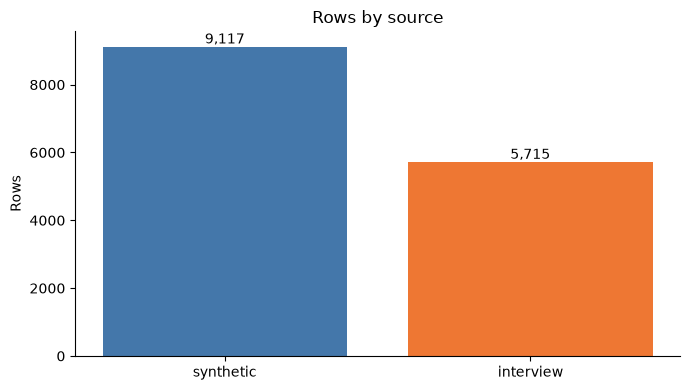

In [3]:
# Cell 3 — Provenance: synthetic GPT-3.5 dialogues vs caregiver interviews
# Exact (input, output) content match against the two source CSVs.
df = ft_utils.add_provenance(df, DKEY)
counts = df["source"].value_counts()
print(counts)

colors = {"synthetic": C_SYN, "interview": C_ITV}
plt.figure(figsize=(7, 4))
bars = plt.bar(counts.index, counts.values,
               color=[colors.get(s, "#999999") for s in counts.index])
plt.bar_label(bars, fmt="{:,.0f}")
plt.title("Rows by source")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — One sample from each source
for src in ("synthetic", "interview"):
    row = df[df["source"] == src].iloc[0]
    print(f"--- {src} ---")
    print(f"INPUT:  {row['input'][:300]}...")
    print(f"OUTPUT: {row['output'][:300]}...")
    print()

--- synthetic ---
INPUT:  I think I might be developing a substance abuse problem. Lately, I've been relying on alcohol as a way to cope with my emotions and escape from reality. It started off as occasional drinking, but now it has become a daily habit. I'm worried about the impact it's having on my physical and mental well...
OUTPUT: I'm really glad that you reached out and shared what you've been going through. It takes a lot of courage to acknowledge and address these concerns. I can understand how relying on alcohol as a coping mechanism might feel like an escape from reality, but it's important to remember that there are hea...

--- interview ---
INPUT:  I've been struggling with my mental health for a while now, and I can't seem to find a way to cope with it. I've tried visualization, positive thinking, and even medication, but nothing seems to work. I've been feeling lost and helpless, and I don't know what to do next. My mind is a whirlwind of th...
OUTPUT: I understand that y

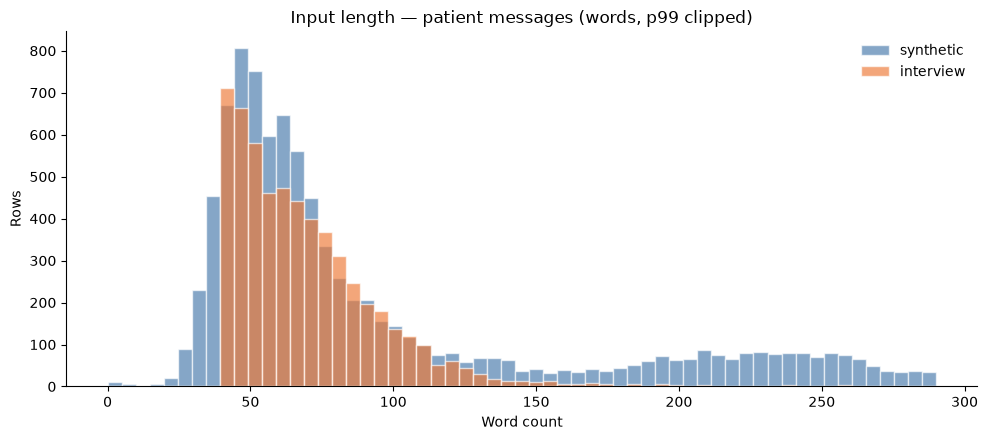

Median input words by source:
source
interview    63.0
synthetic    66.0
Name: input_words, dtype: float64


In [5]:
# Cell 5 — Input length by source (word count)
df["input_words"] = df["input"].str.split().str.len()
df["output_words"] = df["output"].str.split().str.len()

plt.figure(figsize=(10, 4.5))
bins = np.linspace(0, df["input_words"].quantile(0.99), 60)   # clip top-1% tail
for src, color in [("synthetic", C_SYN), ("interview", C_ITV)]:
    plt.hist(df.loc[df["source"] == src, "input_words"], bins=bins,
             alpha=0.65, color=color, edgecolor="white", label=src)
plt.title("Input length — patient messages (words, p99 clipped)")
plt.xlabel("Word count")
plt.ylabel("Rows")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
print("Median input words by source:")
print(df.groupby("source")["input_words"].median())

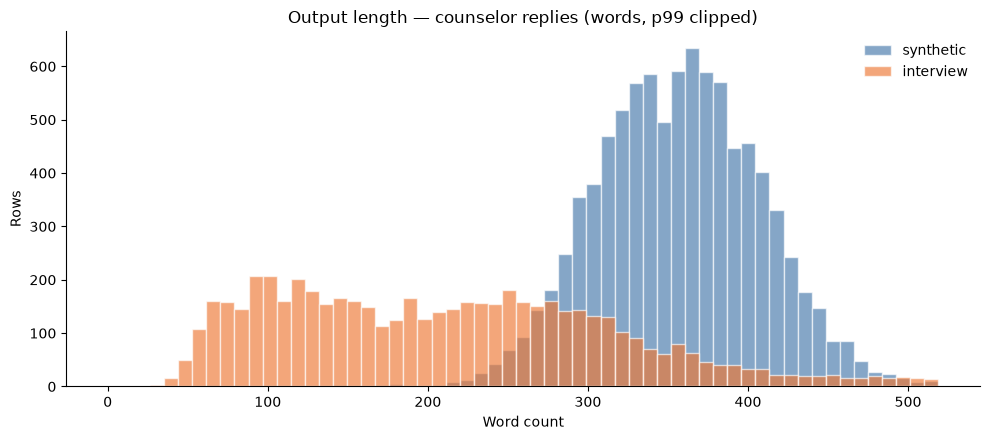

Median output words by source:
source
interview    209.0
synthetic    357.0
Name: output_words, dtype: float64


In [6]:
# Cell 6 — Output length by source (word count)
plt.figure(figsize=(10, 4.5))
bins = np.linspace(0, df["output_words"].quantile(0.99), 60)
for src, color in [("synthetic", C_SYN), ("interview", C_ITV)]:
    plt.hist(df.loc[df["source"] == src, "output_words"], bins=bins,
             alpha=0.65, color=color, edgecolor="white", label=src)
plt.title("Output length — counselor replies (words, p99 clipped)")
plt.xlabel("Word count")
plt.ylabel("Rows")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
print("Median output words by source:")
print(df.groupby("source")["output_words"].median())

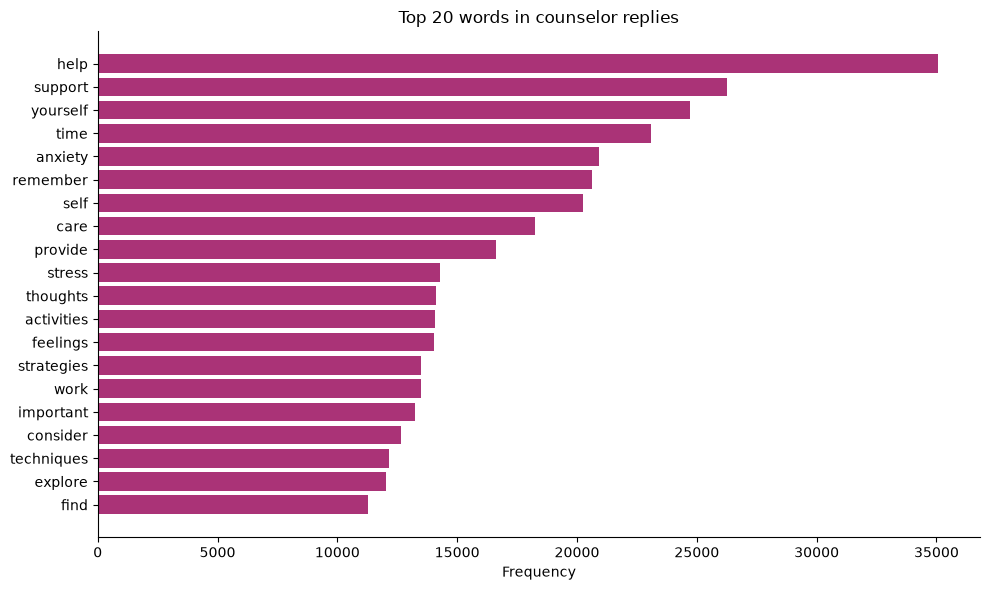

In [7]:
stopwords = {"the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
             "have", "has", "had", "do", "does", "did", "will", "would", "could",
             "should", "may", "might", "shall", "can", "need", "dare", "to", "of",
             "in", "for", "on", "with", "at", "by", "from", "as", "into", "through",
             "during", "before", "after", "and", "but", "or", "nor", "not", "so",
             "yet", "both", "either", "neither", "each", "every", "all", "any",
             "few", "more", "most", "other", "some", "such", "no", "only", "own",
             "same", "than", "too", "very", "just", "because", "if", "when", "where",
             "how", "what", "which", "who", "whom", "this", "that", "these", "those",
             "i", "me", "my", "myself", "we", "our", "ours", "you", "your", "yours",
             "he", "him", "his", "she", "her", "hers", "it", "its", "they", "them",
             "their", "theirs", "about", "up", "out", "also", "like", "well", "even"}

# Cell 7 — Top 20 words in counselor replies (excl. stopwords)
words = []
for text in df["output"]:
    words.extend(w for w in re.findall(r"[a-z]+", text.lower())
                 if w not in stopwords and len(w) > 2)
top20 = Counter(words).most_common(20)
labels, counts = zip(*top20)

plt.figure(figsize=(10, 6))
plt.barh(list(reversed(labels)), list(reversed(counts)), color=C_WORDS)
plt.title("Top 20 words in counselor replies")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 — Token statistics vs the 1024-token training window
enc = tiktoken.get_encoding("cl100k_base")  # approximation; the real tokenizers differ slightly
in_tok = df["input"].map(lambda t: len(enc.encode(t)))
out_tok = df["output"].map(lambda t: len(enc.encode(t)))
total = in_tok + out_tok + 20  # +20 ~ chat-template scaffolding (no system prompt)

max_len = ft_utils.CFG["training"]["max_seq_length"]
print(f"Input tokens:  mean {in_tok.mean():.0f} | median {in_tok.median():.0f} | max {in_tok.max()}")
print(f"Output tokens: mean {out_tok.mean():.0f} | median {out_tok.median():.0f} | max {out_tok.max()}")
print(f"Full example (system+input+output+template): median {total.median():.0f} | "
      f"p95 {total.quantile(0.95):.0f} | max {total.max()}")
print(f"Examples fitting in max_seq_length={max_len}: {(total <= max_len).mean() * 100:.1f}%")
print("\nMedian output tokens by source:")
print(out_tok.groupby(df["source"]).median())

Input tokens:  mean 102 | median 76 | max 443
Output tokens: mean 356 | median 380 | max 767
Full example (system+input+output+template): median 482 | p95 764 | max 873
Examples fitting in max_seq_length=1024: 100.0%

Median output tokens by source:
source
interview    245.0
synthetic    418.0
Name: output, dtype: float64


rows before filters: 15978
  drop placeholder_reply                395 rows (2.5%)
  drop letter_reply                       1 rows (0.0%)
  drop too_long_over_700_words          785 rows (4.9%)
total dropped: 1146 (7.2%)  ->  kept: 14832

too-long rows: 785 | total words median 762 | max 3273
3 longest (these would lose their <end_of_turn> label if trained on):
  [3273 words] IN:  Dear counselor,

I'm seeking counseling as I've been facing challenges in my relationships, especial
                 OUT: Dear [Patient],

Thank you for reaching out and sharing your concerns regarding various aspects of your life. I can understand how challengi
  [2200 words] IN:  I hope to find ways to manage my anxiety and reduce its impact on my daily life.

I've been feeling 
                 OUT: It's evident that you are experiencing intense anxiety, and it's admirable that you're seeking ways to manage it and reduce its impact on yo
  [2135 words] IN:  My goal for this counseling session is to addre

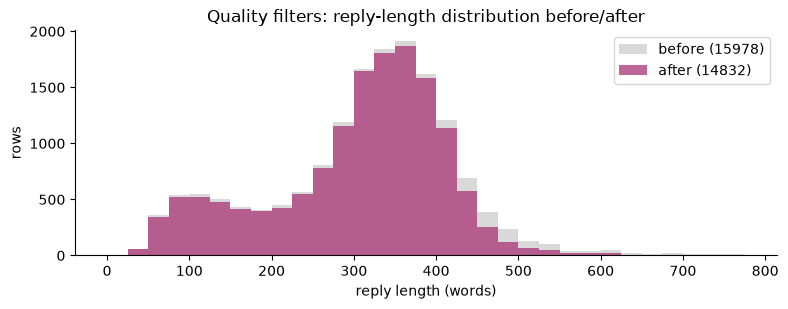

In [9]:
# Cell 8b — Preprocessing: quality filters (config.yaml `preprocess`)
# These run inside ft_utils.load_raw() BEFORE the split, so the cached
# train/val/test files are already filtered. Shown here for transparency.
clean = ft_utils.load_raw(DKEY, apply_filters=False)   # cleaned + deduped, unfiltered
masks = ft_utils.quality_filter_masks(clean)

print(f"rows before filters: {len(clean)}")
for rule, mask in masks.items():
    print(f"  drop {rule:30s} {mask.sum():5d} rows ({mask.sum()/len(clean)*100:.1f}%)")
drop = pd.concat(masks, axis=1).any(axis=1)
print(f"total dropped: {drop.sum()} ({drop.sum()/len(clean)*100:.1f}%)  ->  kept: {(~drop).sum()}")

# the TOO-LONG rows: how long are they, and what do they look like
long_key = next(k for k in masks if k.startswith("too_long"))
too_long = clean[masks[long_key]].copy()
too_long["total_words"] = (too_long["input"].str.split().str.len()
                           + too_long["output"].str.split().str.len())
print(f"\ntoo-long rows: {len(too_long)} | total words median "
      f"{too_long['total_words'].median():.0f} | max {too_long['total_words'].max()}")
print("3 longest (these would lose their <end_of_turn> label if trained on):")
for _, r in too_long.nlargest(3, "total_words").iterrows():
    print(f"  [{r['total_words']} words] IN:  {r['input'][:100]}")
    print(f"                 OUT: {r['output'][:140]}")

# reply-length distribution before vs after filtering
fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.arange(0, 800, 25)
ax.hist(clean["output"].str.split().str.len(), bins=bins, alpha=.55,
        color="#BBBBBB", label=f"before ({len(clean)})")
ax.hist(clean[~drop]["output"].str.split().str.len(), bins=bins, alpha=.75,
        color=C_WORDS, label=f"after ({(~drop).sum()})")
ax.set_xlabel("reply length (words)"); ax.set_ylabel("rows")
ax.set_title("Quality filters: reply-length distribution before/after")
ax.legend(); plt.tight_layout(); plt.show()

In [10]:
# Cell 9 — Grouped 70/20/10 split (cached to data/.../processed/mentalchat16k/)
# Some patient texts repeat with different counselor answers; grouping by user
# text keeps each one inside a single split (~99% of groups are singletons,
# so ratios stay ~70/20/10).
train_df, val_df, test_df = ft_utils.load_and_split(DKEY)
n = len(train_df) + len(val_df) + len(test_df)
for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s}: {len(part):6,} rows ({len(part) / n * 100:.1f}%) | "
          f"unique inputs: {part['input'].nunique():,}")

tr, va, te = set(train_df["input"]), set(val_df["input"]), set(test_df["input"])
print(f"\nLeakage check — shared inputs across splits: "
      f"train-val={len(tr & va)}, train-test={len(tr & te)}, val-test={len(va & te)}")
assert not (tr & va) and not (tr & te) and not (va & te), "user-text leakage across splits!"
print("OK: no patient text appears in more than one split.")

train: 10,383 rows (70.0%) | unique inputs: 10,303
val  :  2,966 rows (20.0%) | unique inputs: 2,950
test :  1,483 rows (10.0%) | unique inputs: 1,470

Leakage check — shared inputs across splits: train-val=0, train-test=0, val-test=0
OK: no patient text appears in more than one split.


## Summary

| Metric | Value |
|---|---|
| Raw rows | 16,084 |
| Sources | ~10K synthetic GPT-3.5 + ~6K paraphrased caregiver interviews (100% provenance match) |
| `instruction` column | one constant boilerplate string → dropped |
| Cleaned rows | *(see Cell 2)* |
| Split | 70/20/10 **grouped by patient text**, seed 42 |

**Observations**

1. The dataset is two populations in one file: synthetic dialogues and caregiver-interview paraphrases differ visibly in input and output length (Cells 5–6) — worth remembering when interpreting per-model results.
2. The constant `instruction` column carries no per-row signal and would duplicate our system prompt, so only `input` → `output` is used (config: `use_instruction_field: false`).
3. Cell 8 shows the share of full formatted examples fitting in the 1024-token window; long interview replies dominate the tail.
4. The grouped split fixes the ~10-input leakage the prior row-level split had, at negligible cost to the ratios. Splits are cached under `data/mh_conversation/processed/mentalchat16k/` and reused verbatim by `train.ipynb`.